In [2]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx import ego_graph, Graph
import numpy as np
from pyod.models.lof import LOF
from sklearn.linear_model import LinearRegression
from torch_geometric.nn import GCNConv

In [3]:
# Load data and build graph
astroph_data = np.loadtxt("data/ca-AstroPh.txt", dtype=int, comments="#")
drawing_graph = Graph()
for node1, node2 in astroph_data[:1500]:
    if drawing_graph.has_edge(node1, node2):
        drawing_graph[node1][node2]["weight"] += 1
    else:
        drawing_graph.add_edge(node1, node2, weight=1)
astroph_graph = nx.Graph(drawing_graph)
# astroph_graph = Graph()
# for node1, node2 in astroph_data:
#     if astroph_graph.has_edge(node1, node2):
#         astroph_graph[node1][node2]["weight"] += 1
#     else:
#         astroph_graph.add_edge(node1, node2, weight=1)

In [4]:
for node in astroph_graph.nodes:
    egonet: Graph = ego_graph(astroph_graph, node)
    n_neighbors = egonet.number_of_nodes()
    n_edges = egonet.number_of_edges()
    total_weight = sum([egonet[node][neighbor]["weight"] for neighbor in egonet.neighbors(node)])
    # Build adjacency matrix
    adj_matrix = np.zeros((n_neighbors, n_neighbors))
    for idx1, node1 in enumerate(egonet.nodes):
        for idx2, node2 in enumerate(egonet.nodes):
            if egonet.has_edge(node1, node2) or egonet.has_edge(node2, node1):
                adj_matrix[idx1, idx2] = egonet[node1][node2]["weight"]
    # Extract principal eigenvalue
    eigresult = np.linalg.eigh(adj_matrix)
    eigvalue = eigresult.eigenvalues[-1]
    # Set attributes
    nx.set_node_attributes(
        astroph_graph,
        {node: {"n_neighbors": n_neighbors, "n_edges": n_edges, "total_weight": total_weight, "eigvalue": eigvalue}},
    )

In [5]:
# Extract features
n_neighbors_dict = nx.get_node_attributes(astroph_graph, "n_neighbors")
n_edges_dict = nx.get_node_attributes(astroph_graph, "n_edges")
X = np.array([n_neighbors_dict[node] for node in astroph_graph.nodes]).reshape(-1, 1)
y = np.array([n_edges_dict[node] for node in astroph_graph.nodes], dtype=np.float64).reshape(-1, 1)
X_log = np.log(X)
y_log = np.log(y)

In [6]:
# Train linear regression model on log features
linreg = LinearRegression()
linreg.fit(X_log, y_log)
preds_log = linreg.predict(X_log)
preds = np.exp(preds_log)
scores = np.maximum(y, preds) / np.minimum(y, preds) * np.log(np.abs(y - preds) + 1)
scores = np.squeeze(scores)

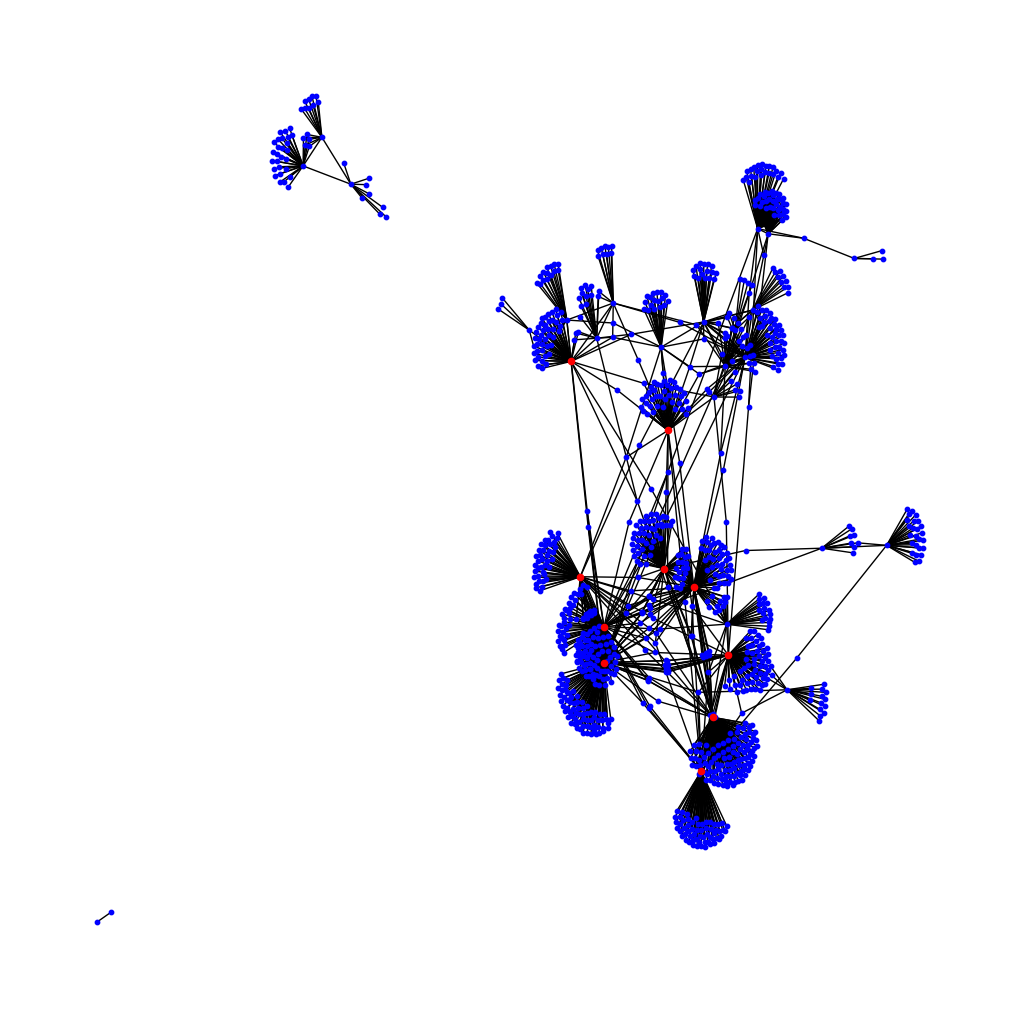

In [15]:
# Draw graph
args = np.argsort(scores)[::-1]
pos = nx.spring_layout(drawing_graph)
graph_nodes = list(astroph_graph.nodes)
top_n = 10
top_anomalies = [graph_nodes[i] for i in args[:top_n] if graph_nodes[i]]
# Draw top_anomalies with red color
plt.figure(figsize=(10, 10))
nx.draw(drawing_graph, pos, node_color="blue", with_labels=False, node_size=10)
nx.draw_networkx_nodes(drawing_graph, pos, nodelist=top_anomalies, node_color="red", node_size=20)
plt.savefig("plots/ex1 - top 10 anomalies.png")

c:\Users\popas\anaconda3\envs\ad\Lib\site-packages\pyod\models\base.py:423: UserWarning: y should not be presented in unsupervised learning.
  warnings.warn(


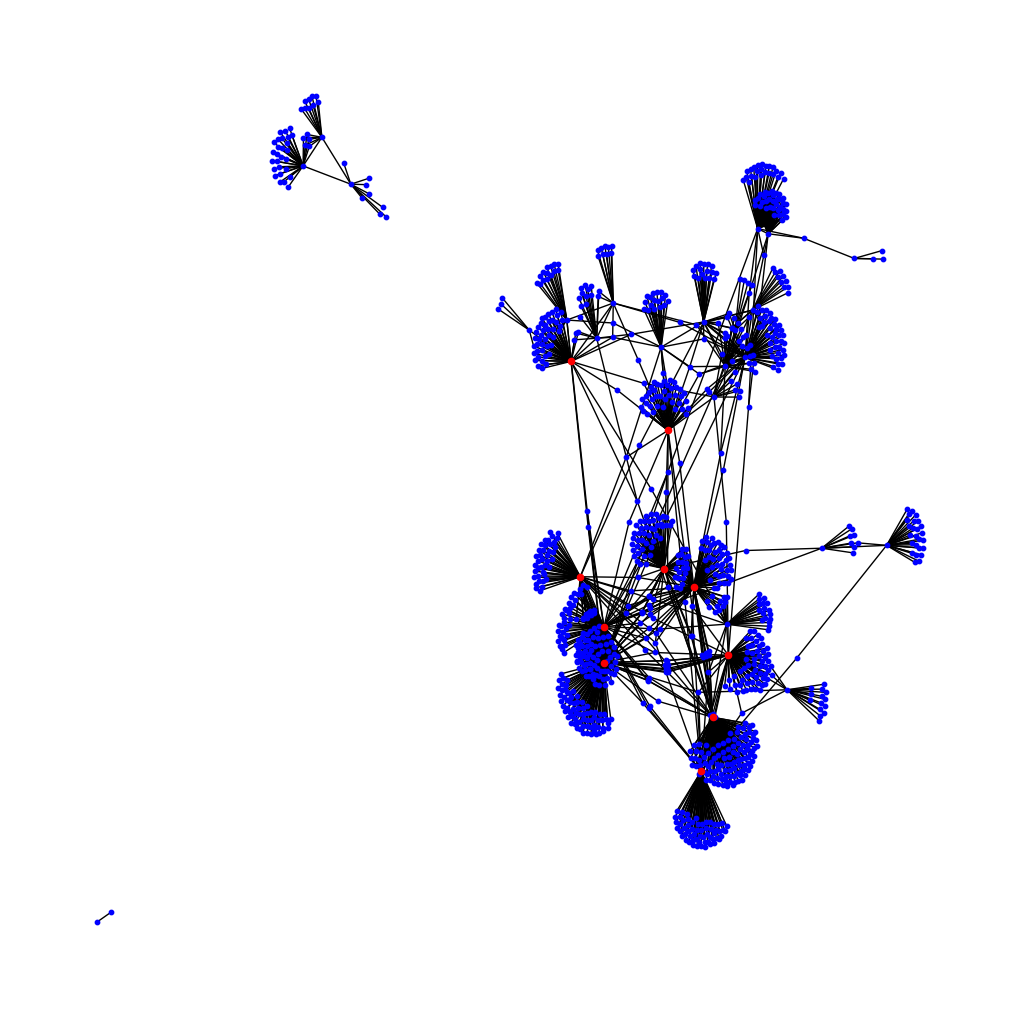

In [20]:
lof = LOF()
lof.fit(X, y)
lof_scores = lof.predict(X)
m0, std0 = np.mean(scores), np.std(scores)
m1, std1 = np.mean(lof_scores), np.std(lof_scores)
modified_scores = (scores - m0) / std0 + (lof_scores - m1) / std1
modified_args = np.argsort(modified_scores)[::-1]
modified_top_anomalies = [graph_nodes[i] for i in modified_args[:top_n] if graph_nodes[i]]
# Draw top_anomalies with green color
plt.figure(figsize=(10, 10))
nx.draw(drawing_graph, pos, node_color="blue", with_labels=False, node_size=10)
nx.draw_networkx_nodes(drawing_graph, pos, nodelist=modified_top_anomalies, node_color="red", node_size=20)
plt.savefig("plots/ex1 - top 10 modified anomalies.png")